# TP : Régression Linéaire Simple en Python

## Objectif général

Ce notebook a un double objectif :

- **Cours** : comprendre la régression linéaire simple (intuition, mathématiques, évaluation)
- **TP** : implémenter un modèle de régression linéaire simple en Python

Nous utilisons l’écosystème **NumPy, Pandas, Matplotlib, Plotly et scikit-learn**.


## 1. Rappel théorique : qu’est-ce que la régression linéaire simple ?

La régression linéaire simple cherche à modéliser la relation entre :

- une variable explicative **X**
- une variable cible **y**

en supposant une relation **linéaire**.

### Modèle mathématique

$ y = ax + b $

- **a** : coefficient directeur (pente)
- **b** : intercept (ordonnée à l’origine)

Interprétation :
- si \(a > 0\), y augmente quand x augmente
- si \(a < 0\), y diminue quand x augmente


## 2. Import des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Rôle des bibliothèques

- **Pandas** : manipulation et analyse de données
- **Matplotlib / Plotly** : visualisation
- **scikit-learn** : modèles de machine learning


## 3. Chargement du dataset Boston Housing

In [2]:
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### Variables du dataset

- **MEDV** : prix médian des maisons (variable cible)
- Les autres colonnes sont des variables explicatives

Nous allons volontairement utiliser **une seule variable explicative**.


## 4. Pourquoi choisir uniquement RM ? (choix pédagogique)

Nous étudions ici une **régression linéaire simple**, donc :

- **1 variable X**
- **1 variable y**

Nous choisissons :
- **X = RM** : nombre moyen de pièces par maison
- **y = MEDV** : prix des maisons

### Pourquoi RM ?

- Variable intuitive
- Relation presque linéaire avec le prix
- Interprétation simple du coefficient

Exemple : *"Ajouter une pièce augmente le prix moyen de X"*


In [3]:

X = df[['RM']]
y = df['MEDV']


## 5. Visualisation des données

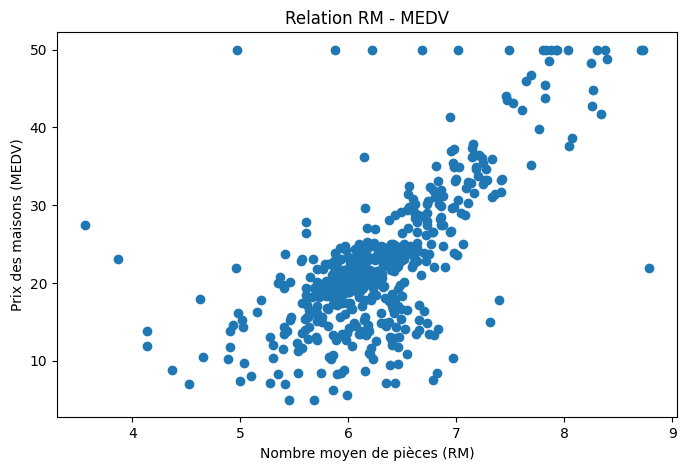

In [4]:

plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.xlabel("Nombre moyen de pièces (RM)")
plt.ylabel("Prix des maisons (MEDV)")
plt.title("Relation RM - MEDV")
plt.show()


Chaque point représente une maison.

Si les points suivent une tendance globale linéaire, un modèle linéaire est pertinent.


## 6. Séparation du jeu de données : Train / Test

### Pourquoi séparer les données ?

Objectif : **évaluer la capacité du modèle à généraliser**.

- **Train set** : apprentissage du modèle
- **Test set** : données jamais vues

Sans cette séparation :
- le modèle peut mémoriser
- les scores seraient trompeurs


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 7. Entraînement du modèle

Le modèle cherche les paramètres **a** et **b** qui minimisent l’erreur entre :
- valeurs réelles
- valeurs prédites

Méthode utilisée : **moindres carrés**.


In [6]:

model = LinearRegression()
model.fit(X_train, y_train)

model.coef_[0], model.intercept_


(np.float64(9.348301406497722), np.float64(-36.24631889813792))

## 8. Prédiction

In [7]:

y_pred = model.predict(X_test)


## 9. Évaluation du modèle

### Mean Squared Error (MSE)

$ MSE = \frac{1}{n} \sum (y - y_{pred})^2 $

- plus petit = meilleur
- pénalise fortement les grosses erreurs

### Coefficient de détermination R²

La formule mathématique :

$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$

### Explications

- $y_i$ : valeur réelle  
- $\hat{y}_i$ : valeur prédite par le modèle  
- $\bar{y}$ : moyenne des valeurs réelles  
- $n$ : nombre d’observations  

### Interprétation

- $R^2 = 1$ → modèle parfait  
- $R^2 = 0$ → aussi performant que prédire la moyenne  
- $0 < R^2 < 1$ → proportion de la variance expliquée par le modèle



In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(46.144775347317264, 0.3707569232254778)

## 10. Visualisation de la droite de régression

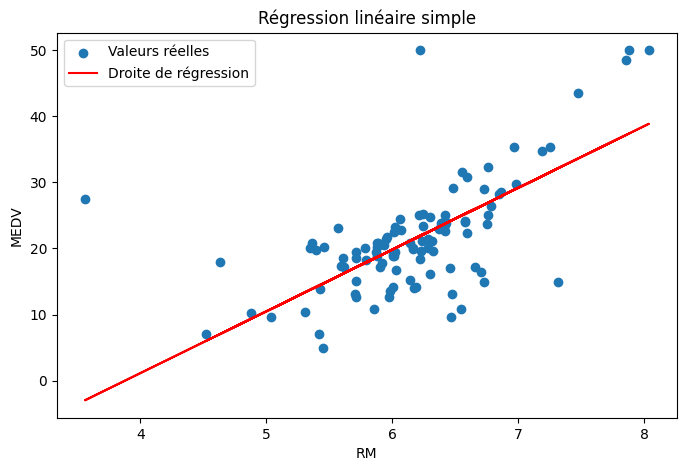

In [9]:

plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, label="Valeurs réelles")
plt.plot(X_test, y_pred, color="red", label="Droite de régression")
plt.xlabel("RM")
plt.ylabel("MEDV")
plt.legend()
plt.title("Régression linéaire simple")
plt.show()


👉 La droite représente la **meilleure approximation linéaire** des données.

Plus les points sont proches de la droite, meilleur est le modèle.


## 11. Conclusion pédagogique

- La régression linéaire simple est un **modèle explicatif**
- Elle permet de comprendre les relations entre variables
- Elle sert de base à des modèles plus complexes

Prochaine étape naturelle : **régression linéaire multiple**
